In [1]:
# imports

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt

In [2]:
df_stroke = pd.read_csv('healthcare-dataset-stroke-data.csv')
print(df_stroke.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


In [3]:
print(df_stroke.isna().sum())
df_stroke = df_stroke.dropna()
df_stroke = df_stroke.drop(columns=['id'])

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [4]:
y = df_stroke[['stroke']].copy()
df_stroke = df_stroke.drop(columns=['stroke'])

In [5]:
gender_col = df_stroke['gender']  # still categorical

# Remove gender from features
df_stroke = df_stroke.drop(columns=['gender'])

cat_cols = ['hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
X = pd.get_dummies(df_stroke, columns=cat_cols, drop_first=True, dtype=int)
y = pd.get_dummies(y, drop_first=True, dtype=int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

cols_to_scale = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [6]:
gender_train, gender_test = train_test_split(gender_col, test_size=0.2, random_state=42)

gender_test = (gender_test == 'Male').astype(int)
gender_train = (gender_train == 'Male').astype(int)

### Classical Logit: Useless model

In [7]:
logistic_model=LogisticRegression()
logistic_model.fit(X_train,y_train.values.ravel())
y_pred=logistic_model.predict(X_test)

accuracy_score(y_test.values.ravel(),y_pred) # not good

0.9460285132382892

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve
y_prob = logistic_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test.values.ravel(), y_prob)
print(auc)

0.8545199748156874


In [9]:
cm = confusion_matrix(y_test.values.ravel(), y_pred)
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

TPR = TP / (TP + FN)  # True Positive Rate
TNR = TN / (TN + FP)  # True Negative Rate
FNR = FN / (TP + FN)  # False Negative Rate
FPR = FP / (TN + FP)  # False Positive Rate

# Output metrics
print(f"Confusion Matrix:\n{cm}")
print(f"TPR (True Positive Rate): {TPR}")
print(f"TNR (True Negative Rate): {TNR}")
print(f"FNR (False Negative Rate): {FNR}")
print(f"FPR (False Positive Rate): {FPR}")

Confusion Matrix:
[[929   0]
 [ 53   0]]
TPR (True Positive Rate): 0.0
TNR (True Negative Rate): 1.0
FNR (False Negative Rate): 1.0
FPR (False Positive Rate): 0.0


In [10]:
def true_positive_rate(y_true_group, y_pred_group):
    tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

# Create results list
results_list = []

In [11]:
y_true = y_test.values.ravel()
y_pred_unweighted = y_pred.copy()  # save this before you overwrite it with the next model

# Gender masks
male_idx = (gender_test == 1)
female_idx = (gender_test == 0)


results_list.append({
    'Model': 'LogReg',
    'Accuracy': accuracy_score(y_true, y_pred_unweighted),
    'TPR_Male': true_positive_rate(y_true[male_idx], y_pred_unweighted[male_idx]),
    'TPR_Female': true_positive_rate(y_true[female_idx], y_pred_unweighted[female_idx]),
    'TPR_Gap': abs(true_positive_rate(y_true[male_idx], y_pred_unweighted[male_idx]) -
                   true_positive_rate(y_true[female_idx], y_pred_unweighted[female_idx]))
})

I don't use the fairness correction metrics here, since this model is garbage

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

def compute_group_tpr_with_bootstrap_ci(X, y, gender, model_fn, cols_to_scale, n_splits=50, test_size=0.2, ci_level=95):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    tpr_male_list = []
    tpr_female_list = []
    accuracy_list = []

    for train_idx, test_idx in splitter.split(X, y):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # Fit model
        model = model_fn()
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)

        # Convert to arrays
        y_true = y_test.values.ravel()
        y_hat = y_pred

        # Accuracy for this split
        acc = accuracy_score(y_true, y_hat)
        accuracy_list.append(acc)

        # Male = 1, Female = 0
        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else np.nan

        tpr_male = tpr(y_true[male_idx], y_hat[male_idx])
        tpr_female = tpr(y_true[female_idx], y_hat[female_idx])

        if not np.isnan(tpr_male):
            tpr_male_list.append(tpr_male)
        if not np.isnan(tpr_female):
            tpr_female_list.append(tpr_female)

    def bootstrap_ci(values, ci=95, n_bootstrap=10000):
        values = np.array(values)
        if len(values) == 0:
            return np.nan, np.nan
        boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_bootstrap)]
        lower = np.percentile(boot_means, (100 - ci) / 2)
        upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
        mean = np.mean(values)
        half_width = (upper - lower) / 2
        return mean, half_width

    def summarize(name, values):
        mean, half_width = bootstrap_ci(values, ci=ci_level)
        print(f"{name}: {mean:.3f} ± {half_width:.3f} ({ci_level}% CI)")

    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)

    # Compute gap using aligned values only
    min_len = min(len(tpr_male_list), len(tpr_female_list))
    gap_list = (np.array(tpr_male_list[:min_len]) - np.array(tpr_female_list[:min_len]))
    summarize("Equalized Odds TPR Gap", gap_list)

    # Accuracy summary
    summarize("Accuracy", accuracy_list)


In [13]:
def logistic():
    return LogisticRegression()

compute_group_tpr_with_bootstrap_ci(
    X=X,
    y=y,
    gender=(gender_col == 'Male').astype(int),  # encode gender
    model_fn=logistic,
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    n_splits=50  # or more if you want tighter intervals
)

TPR Male: 0.012 ± 0.007 (95% CI)
TPR Female: 0.000 ± 0.000 (95% CI)
Equalized Odds TPR Gap: 0.012 ± 0.007 (95% CI)
Accuracy: 0.957 ± 0.000 (95% CI)


In [14]:
import pandas as pd

# Create an empty dataframe
df = pd.DataFrame(columns=["Method", "Accuracy", "CI_lower", "CI_upper"])

# # Append results manually
# row1 = {
#     "Method": "Baseline",
#     "Accuracy": 0.957,
#     "CI_lower": 0.957,  # always just predicts 0
#     "CI_upper": 0.957  
# }
# df = pd.concat([df, pd.DataFrame([row1])], ignore_index=True)

### Class weights logit

In [15]:
logistic_model=LogisticRegression(class_weight="balanced")
logistic_model.fit(X_train,y_train.values.ravel())
y_pred=logistic_model.predict(X_test)

accuracy_score(y_test.values.ravel(),y_pred)

0.7464358452138493

In [16]:
cm = confusion_matrix(y_test.values.ravel(), y_pred)
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

TPR = TP / (TP + FN)  # True Positive Rate
TNR = TN / (TN + FP)  # True Negative Rate
FNR = FN / (TP + FN)  # False Negative Rate
FPR = FP / (TN + FP)  # False Positive Rate

# Output metrics
print(f"TPR (True Positive Rate): {TPR}")
print(f"TNR (True Negative Rate): {TNR}")
print(f"FNR (False Negative Rate): {FNR}")
print(f"FPR (False Positive Rate): {FPR}")

TPR (True Positive Rate): 0.8490566037735849
TNR (True Negative Rate): 0.7405812701829925
FNR (False Negative Rate): 0.1509433962264151
FPR (False Positive Rate): 0.25941872981700753


In [17]:
y_pred_probs = logistic_model.predict_proba(X_test)[:, 1]

In [18]:
# rewrite this


from sklearn.metrics import confusion_matrix

# Convert y_test and y_pred to 1D arrays
y_true = y_test.values.ravel()
y_hat = y_pred

def true_positive_rate(y_true_group, y_pred_group):
    tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

# Split by gender
male_idx = (gender_test == 1)
female_idx = (gender_test == 0)

# TPR for each group
tpr_male = true_positive_rate(y_true[male_idx], y_hat[male_idx])
tpr_female = true_positive_rate(y_true[female_idx], y_hat[female_idx])

print("TPR Male:", tpr_male)
print("TPR Female:", tpr_female)

# Equalized odds difference (TPR gap)
equalized_odds_TPR_gap = abs(tpr_male - tpr_female)
print("Equalized Odds TPR Gap:", equalized_odds_TPR_gap)

TPR Male: 0.8888888888888888
TPR Female: 0.8285714285714286
Equalized Odds TPR Gap: 0.060317460317460214


In [19]:
y_pred_balanced = y_pred.copy()  # again, save before overwriting later

results_list.append({
    'Model': 'LogReg_balanced',
    'Accuracy': accuracy_score(y_true, y_pred_balanced),
    'TPR_Male': true_positive_rate(y_true[male_idx], y_pred_balanced[male_idx]),
    'TPR_Female': true_positive_rate(y_true[female_idx], y_pred_balanced[female_idx]),
    'TPR_Gap': abs(true_positive_rate(y_true[male_idx], y_pred_balanced[male_idx]) -
                   true_positive_rate(y_true[female_idx], y_pred_balanced[female_idx]))
})

In [20]:
results_list # seru na to

[{'Model': 'LogReg',
  'Accuracy': 0.9460285132382892,
  'TPR_Male': np.float64(0.0),
  'TPR_Female': np.float64(0.0),
  'TPR_Gap': np.float64(0.0)},
 {'Model': 'LogReg_balanced',
  'Accuracy': 0.7464358452138493,
  'TPR_Male': np.float64(0.8888888888888888),
  'TPR_Female': np.float64(0.8285714285714286),
  'TPR_Gap': np.float64(0.060317460317460214)}]

### Add confidence bands

In [21]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

def compute_group_tpr_with_ci(X, y, gender, model_fn, cols_to_scale, n_splits=50, test_size=0.2):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    tpr_male_list = []
    tpr_female_list = []

    for train_idx, test_idx in splitter.split(X, y):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # Fit model
        model = model_fn()
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)

        # Convert to 1D arrays
        y_true = y_test.values.ravel()
        y_hat = y_pred

        # Male = 1, Female = 0
        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else 0

        tpr_male = tpr(y_true[male_idx], y_hat[male_idx])
        tpr_female = tpr(y_true[female_idx], y_hat[female_idx])

        tpr_male_list.append(tpr_male)
        tpr_female_list.append(tpr_female)

    def summarize(name, values):
        values = np.array(values)
        mean = np.mean(values)
        std = np.std(values)
        ci95 = 1.96 * std / np.sqrt(n_splits)
        print(f"{name}: {mean:.3f} ± {ci95:.3f} (95% CI)")

    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)

    gap_list = np.abs(np.array(tpr_male_list) - np.array(tpr_female_list))
    summarize("Equalized Odds TPR Gap", gap_list)


In [22]:
def logistic_balanced():
    return LogisticRegression(class_weight="balanced")

compute_group_tpr_with_ci(
    X=X,
    y=y,
    gender=(gender_col == 'Male').astype(int),  # encode gender
    model_fn=logistic_balanced,
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    n_splits=50  # or more if you want tighter intervals
)

TPR Male: 0.844 ± 0.023 (95% CI)
TPR Female: 0.770 ± 0.024 (95% CI)
Equalized Odds TPR Gap: 0.114 ± 0.023 (95% CI)


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

def compute_group_tpr_with_bootstrap_ci(X, y, gender, model_fn, cols_to_scale, n_splits=50, test_size=0.2, ci_level=95):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    tpr_male_list = []
    tpr_female_list = []
    accuracy_list = []

    for train_idx, test_idx in splitter.split(X, y):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # Fit model
        model = model_fn()
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)

        # Convert to arrays
        y_true = y_test.values.ravel()
        y_hat = y_pred

        # Compute accuracy
        accuracy = np.mean(y_hat == y_true)
        accuracy_list.append(accuracy)

        # Male = 1, Female = 0
        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else np.nan

        tpr_male = tpr(y_true[male_idx], y_hat[male_idx])
        tpr_female = tpr(y_true[female_idx], y_hat[female_idx])

        if not np.isnan(tpr_male):
            tpr_male_list.append(tpr_male)
        if not np.isnan(tpr_female):
            tpr_female_list.append(tpr_female)

    def bootstrap_ci(values, ci=95, n_bootstrap=10000):
        values = np.array(values)
        if len(values) == 0:
            return np.nan, np.nan
        boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_bootstrap)]
        lower = np.percentile(boot_means, (100 - ci) / 2)
        upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
        mean = np.mean(values)
        half_width = (upper - lower) / 2
        return mean, half_width

    def summarize(name, values):
        mean, half_width = bootstrap_ci(values, ci=ci_level)
        print(f"{name}: {mean:.3f} ± {half_width:.3f} ({ci_level}% CI)")

    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)

    # Compute gap using aligned values only
    min_len = min(len(tpr_male_list), len(tpr_female_list))
    gap_list = (np.array(tpr_male_list[:min_len]) - np.array(tpr_female_list[:min_len]))
    summarize("Equalized Odds TPR Gap", gap_list)

    # Report accuracy and CI
    summarize("Accuracy", accuracy_list)


In [24]:
compute_group_tpr_with_bootstrap_ci(
    X=X,
    y=y,
    gender=(gender_col == 'Male').astype(int),  # encode gender
    model_fn=logistic_balanced,
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    n_splits=50  # or more if you want tighter intervals
)

TPR Male: 0.844 ± 0.022 (95% CI)
TPR Female: 0.770 ± 0.024 (95% CI)
Equalized Odds TPR Gap: 0.073 ± 0.034 (95% CI)
Accuracy: 0.743 ± 0.004 (95% CI)


In [25]:
# Create an empty dataframe
df = pd.DataFrame(columns=["Method", "Accuracy", "CI_lower", "CI_upper"])
row1 = {
    "Method": "Baseline",
    "Accuracy": 0.743,
    "CI_lower": 0.739,  # always just predicts 0
    "CI_upper": 0.747  
}
df = pd.concat([df, pd.DataFrame([row1])], ignore_index=True)

/var/folders/sb/qf31rt690tl85rzl99t4n0600000gn/T/ipykernel_43799/168332164.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row1])], ignore_index=True)


In [26]:
import pandas as pd

# Create an empty dataframe
df_TPR_gap = pd.DataFrame(columns=["Method", "TPR_gap", "CI_lower", "CI_upper"])
row_TPR_1 = {
    "Method": "Baseline",
    "TPR_gap": 0.073,
    "CI_lower": 0.039,  # always just predicts 0
    "CI_upper": 0.107
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_1])], ignore_index=True)


/var/folders/sb/qf31rt690tl85rzl99t4n0600000gn/T/ipykernel_43799/1333368109.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_1])], ignore_index=True)


#### Post-processing: Choose different threshold for women

In [27]:
from sklearn.metrics import confusion_matrix, roc_curve

male_true = y_true[male_idx]
female_true = y_true[female_idx]
male_proba = y_pred_probs[male_idx]
female_proba = y_pred_probs[female_idx]

# Fixed male threshold
threshold_male = 0.5
male_pred = (male_proba > threshold_male).astype(int)

# Function to compute TPR
def compute_tpr(y_true_group, y_pred_group):
    tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

# Target TPR = Male TPR
tpr_male = compute_tpr(male_true, male_pred)
print(f"TPR (Male): {tpr_male:.3f}")

# Find threshold for females to match TPR
fpr, tpr, thresholds = roc_curve(female_true, female_proba)
closest_idx = np.argmin(np.abs(tpr - tpr_male))
threshold_female = thresholds[closest_idx]
print(f"Selected Female Threshold: {threshold_female:.3f}")

# Apply thresholds
y_hat_groupwise = np.zeros_like(y_pred_probs)
y_hat_groupwise[male_idx] = (male_proba > threshold_male).astype(int)
y_hat_groupwise[female_idx] = (female_proba > threshold_female).astype(int)

# Final TPRs
tpr_female_adj = compute_tpr(female_true, y_hat_groupwise[female_idx])
tpr_male_adj = compute_tpr(male_true, y_hat_groupwise[male_idx])
tpr_gap = abs(tpr_female_adj - tpr_male_adj)

# Accuracy
accuracy_adj = accuracy_score(y_true, y_hat_groupwise)

# Print metrics
print(f"TPR (Female, Adjusted): {tpr_female_adj:.3f}")
print(f"TPR (Male, Adjusted):   {tpr_male_adj:.3f}")
print(f"Equal Opportunity Gap:  {tpr_gap:.3f}")
print(f"Accuracy (Adjusted):    {accuracy_adj:.3f}")

TPR (Male): 0.889
Selected Female Threshold: 0.372
TPR (Female, Adjusted): 0.857
TPR (Male, Adjusted):   0.889
Equal Opportunity Gap:  0.032
Accuracy (Adjusted):    0.697


In [28]:
# tradeoff curve?
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
def compute_tpr_fpr(y_true, y_proba, threshold):
    y_pred = (y_proba > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return tpr, fpr


thresholds = np.linspace(0, 1, 500)

tpr_female_curve = []
fpr_female_curve = []

for th in thresholds:
    tpr, fpr = compute_tpr_fpr(female_true, female_proba, th)
    tpr_female_curve.append(tpr)
    fpr_female_curve.append(fpr)

tpr_female_curve = np.array(tpr_female_curve)
fpr_female_curve = np.array(fpr_female_curve)

threshold_male = 0.5
tpr_male, fpr_male = compute_tpr_fpr(male_true, male_proba, threshold_male)



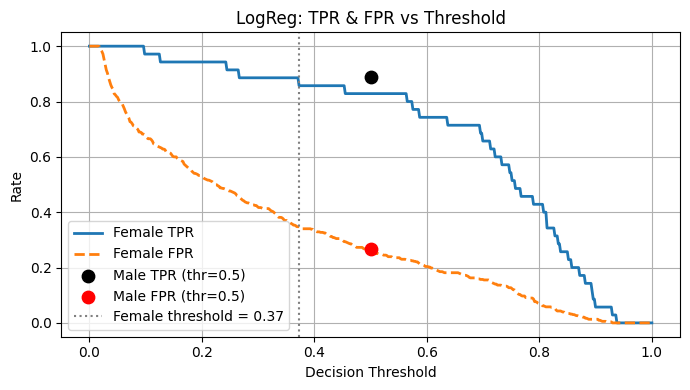

In [29]:
plt.figure(figsize=(7, 4))

# Female curves
plt.plot(thresholds, tpr_female_curve, label="Female TPR", linewidth=2)
plt.plot(thresholds, fpr_female_curve, label="Female FPR", linewidth=2, linestyle="--")

# Male fixed-threshold points
plt.scatter(
    [threshold_male], [tpr_male],
    color="black", s=80, zorder=5, label="Male TPR (thr=0.5)"
)
plt.scatter(
    [threshold_male], [fpr_male],
    color="red", s=80, zorder=5, label="Male FPR (thr=0.5)"
)

# Optional: mark selected female threshold (≈0.37)
plt.axvline(
    x=threshold_female, color="gray", linestyle=":", label=f"Female threshold = {threshold_female:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Rate")
plt.title("LogReg: TPR & FPR vs Threshold")
plt.legend()
plt.grid(True)

plt.savefig("LR_TPR_FPR.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

def compute_tpr_fixed_thresholds(
    X, y, gender, model_fn, cols_to_scale,
    threshold_male=0.5, threshold_female=0.37,
    n_splits=50, test_size=0.2, ci_level=95
):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    tpr_male_list = []
    tpr_female_list = []
    gap_list = []
    acc_list = []

    for train_idx, test_idx in splitter.split(X, y):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # Train model
        model = model_fn()
        model.fit(X_train, y_train.values.ravel())
        y_proba = model.predict_proba(X_test)[:, 1]
        y_true = y_test.values.ravel()

        # Group-based thresholding
        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        y_pred = np.zeros_like(y_proba)
        y_pred[male_idx] = (y_proba[male_idx] > threshold_male).astype(int)
        y_pred[female_idx] = (y_proba[female_idx] > threshold_female).astype(int)

        # Compute TPR
        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else np.nan

        tpr_m = tpr(y_true[male_idx], y_pred[male_idx])
        tpr_f = tpr(y_true[female_idx], y_pred[female_idx])
        acc = accuracy_score(y_true, y_pred)

        if not np.isnan(tpr_m) and not np.isnan(tpr_f):
            tpr_male_list.append(tpr_m)
            tpr_female_list.append(tpr_f)
            gap_list.append((tpr_m - tpr_f))
            acc_list.append(acc)

    # Bootstrapped CI helper
    def bootstrap_ci(values, ci=95, n_bootstrap=10000):
        values = np.array(values)
        if len(values) == 0:
            return np.nan, np.nan
        boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_bootstrap)]
        lower = np.percentile(boot_means, (100 - ci) / 2)
        upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
        mean = np.mean(values)
        half_width = (upper - lower) / 2
        return mean, half_width

    def summarize(name, values):
        mean, half_width = bootstrap_ci(values, ci=ci_level)
        print(f"{name}: {mean:.3f} ± {half_width:.3f} ({ci_level}% CI)")

    print(f"Fixed thresholds: Male = {threshold_male}, Female = {threshold_female}")
    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)
    summarize("Equalized Odds TPR Gap", gap_list)
    summarize("Overall Accuracy", acc_list)


In [31]:
compute_tpr_fixed_thresholds(
    X=X,
    y=y,
    gender=(gender_col == 'Male').astype(int),
    model_fn=logistic_balanced,
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    threshold_male=0.5,
    threshold_female=0.37,
    n_splits=50
)

Fixed thresholds: Male = 0.5, Female = 0.37
TPR Male: 0.844 ± 0.023 (95% CI)
TPR Female: 0.868 ± 0.020 (95% CI)
Equalized Odds TPR Gap: -0.024 ± 0.028 (95% CI)
Overall Accuracy: 0.692 ± 0.004 (95% CI)


In [32]:
row2 = {
    "Method": "FN-aware Thresholding",
    "Accuracy": 0.692,
    "CI_lower": 0.688,  # always just predicts 0
    "CI_upper": 0.696  
}
df = pd.concat([df, pd.DataFrame([row2])], ignore_index=True)

In [33]:
row_TPR_2 = {
    "Method": "FN-aware Thresholding",
    "TPR_gap": -0.024,
    "CI_lower": -0.052,  # always just predicts 0
    "CI_upper": 0.004
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_2])], ignore_index=True)

#### Learning with fairness constraints

This leads to extreme FNR, but does something....

In [34]:
from fairlearn.reductions import DemographicParity, EqualizedOdds, ExponentiatedGradient
from sklearn.linear_model import LogisticRegression

# Logistic regression with Equalized Odds constraints
constraint = EqualizedOdds()
mitigator = ExponentiatedGradient(LogisticRegression(class_weight="balanced"), constraint)
mitigator.fit(X_train, y_train.values.ravel(), sensitive_features=gender_train)

y_hat = mitigator.predict(X_test)

# TPR for each group
tpr_male = true_positive_rate(y_true[male_idx], y_hat[male_idx])
tpr_female = true_positive_rate(y_true[female_idx], y_hat[female_idx])

print("TPR Male:", tpr_male)
print("TPR Female:", tpr_female)

# Equalized odds difference (TPR gap)
equalized_odds_TPR_gap = abs(tpr_male - tpr_female)
print("Equalized Odds TPR Gap:", equalized_odds_TPR_gap)

TPR Male: 1.0
TPR Female: 1.0
Equalized Odds TPR Gap: 0.0


In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from fairlearn.reductions import EqualizedOdds, ExponentiatedGradient
from sklearn.linear_model import LogisticRegression

def compute_bootstrap_fairlearn_equalized_odds(
    X, y, gender, cols_to_scale,
    n_splits=50, test_size=0.2, ci_level=95
):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    tpr_male_list = []
    tpr_female_list = []
    gap_list = []
    acc_list = []

    for train_idx, test_idx in splitter.split(X, y):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale features
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # Fit Fairlearn mitigator with Equalized Odds constraint
        constraint = EqualizedOdds()
        base_model = LogisticRegression(class_weight="balanced", solver="liblinear")
        mitigator = ExponentiatedGradient(base_model, constraints=constraint)
        mitigator.fit(X_train, y_train.values.ravel(), sensitive_features=gender_train)

        y_true = y_test.values.ravel()
        y_hat = mitigator.predict(X_test)

        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else np.nan

        tpr_m = tpr(y_true[male_idx], y_hat[male_idx])
        tpr_f = tpr(y_true[female_idx], y_hat[female_idx])
        acc = accuracy_score(y_true, y_hat)

        if not np.isnan(tpr_m) and not np.isnan(tpr_f):
            tpr_male_list.append(tpr_m)
            tpr_female_list.append(tpr_f)
            gap_list.append((tpr_m - tpr_f))
            acc_list.append(acc)

    def bootstrap_ci(values, ci=95, n_bootstrap=10000):
        values = np.array(values)
        if len(values) == 0:
            return np.nan, np.nan
        boot_means = [np.mean(np.random.choice(values, size=len(values), replace=True)) for _ in range(n_bootstrap)]
        lower = np.percentile(boot_means, (100 - ci) / 2)
        upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
        mean = np.mean(values)
        half_width = (upper - lower) / 2
        return mean, half_width

    def summarize(name, values):
        mean, half_width = bootstrap_ci(values, ci=ci_level)
        print(f"{name}: {mean:.3f} ± {half_width:.3f} ({ci_level}% CI)")

    print("Fairlearn: Equalized Odds via Exponentiated Gradient")
    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)
    summarize("Equalized Odds TPR Gap", gap_list)
    summarize("Accuracy", acc_list)


In [36]:
compute_bootstrap_fairlearn_equalized_odds(
    X=X,
    y=y,
    gender=(gender_col == 'Male').astype(int),
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    n_splits=50
)


Fairlearn: Equalized Odds via Exponentiated Gradient
TPR Male: 0.892 ± 0.056 (95% CI)
TPR Female: 0.857 ± 0.051 (95% CI)
Equalized Odds TPR Gap: 0.035 ± 0.027 (95% CI)
Accuracy: 0.339 ± 0.064 (95% CI)


In [37]:
row3 = {
    "Method": "Equalized Odds (fairlearn)",
    "Accuracy": 0.341,
    "CI_lower": 0.276,  # always just predicts 0
    "CI_upper": 0.406  
}
df = pd.concat([df, pd.DataFrame([row3])], ignore_index=True)

In [38]:
row_TPR_3 = {
    "Method": "Equalized Odds (fairlearn)",
    "TPR_gap": 0.052,
    "CI_lower": 0.028,  # always just predicts 0
    "CI_upper": 0.076
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_3])], ignore_index=True)

In [39]:
cm = confusion_matrix(y_test.values.ravel(), y_hat)
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

TPR = TP / (TP + FN)  # True Positive Rate
TNR = TN / (TN + FP)  # True Negative Rate
FNR = FN / (TP + FN)  # False Negative Rate
FPR = FP / (TN + FP)  # False Positive Rate

# Output metrics
print(f"TPR (True Positive Rate): {TPR}")
print(f"TNR (True Negative Rate): {TNR}")
print(f"FNR (False Negative Rate): {FNR}")
print(f"FPR (False Positive Rate): {FPR}")

TPR (True Positive Rate): 1.0
TNR (True Negative Rate): 0.12486544671689989
FNR (False Negative Rate): 0.0
FPR (False Positive Rate): 0.8751345532831001


Maybe try different thresholds? Becasue the FPR is insane

In [40]:
# try different thresholds???
# Get the classifiers and their weights
classifiers = mitigator.predictors_
weights = mitigator.weights_

# Compute the weighted probability predictions
probs = np.zeros(X_test.shape[0])

for clf, w in zip(classifiers, weights):
    probs += w * clf.predict_proba(X_test)[:, 1]

# Now you have the soft predictions
y_probs = probs

thresholds = np.linspace(0.85, 0.95, 20)
results = []

for thresh in thresholds:
    y_hat_thresh = (y_probs >= thresh).astype(int)

    tpr_male = true_positive_rate(y_true[male_idx], y_hat_thresh[male_idx])
    tpr_female = true_positive_rate(y_true[female_idx], y_hat_thresh[female_idx])
    eq_odds_gap = abs(tpr_male - tpr_female)
    overall_acc = accuracy_score(y_true, y_hat_thresh)

    results.append((thresh, tpr_male, tpr_female, eq_odds_gap, overall_acc))

import pandas as pd
results_df = pd.DataFrame(results, columns=['threshold', 'TPR_male', 'TPR_female', 'TPR_gap', 'accuracy'])
print(results_df.sort_values('TPR_gap').head(5))

    threshold  TPR_male  TPR_female   TPR_gap  accuracy
9    0.897368  0.833333    0.828571  0.004762  0.745418
8    0.892105  0.888889    0.857143  0.031746  0.721996
17   0.939474  0.388889    0.457143  0.068254  0.887984
0    0.850000  1.000000    0.914286  0.085714  0.498982
2    0.860526  1.000000    0.914286  0.085714  0.564155


I guess the first line from this could be presented?

In [41]:
# confidence
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from sklearn.linear_model import LogisticRegression
import numpy as np

def fairlearn_with_ci(X, y, gender, cols_to_scale, threshold=0.897368, n_splits=30, test_size=0.2):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    tpr_male_list = []
    tpr_female_list = []
    gap_list = []
    acc_list = []

    for train_idx, test_idx in splitter.split(X, y):
        # Split data
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # Train Fairlearn model
        base_model = LogisticRegression(class_weight='balanced')
        constraint = EqualizedOdds()
        mitigator = ExponentiatedGradient(base_model, constraint)
        mitigator.fit(X_train, y_train.values.ravel(), sensitive_features=gender_train)

        # Ensemble soft probabilities
        probs = np.zeros(X_test.shape[0])
        for clf, weight in zip(mitigator.predictors_, mitigator.weights_):
            probs += weight * clf.predict_proba(X_test)[:, 1]

        # Apply threshold
        y_pred = (probs >= threshold).astype(int)
        y_true = y_test.values.ravel()

        # Group masks
        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else 0

        tpr_m = tpr(y_true[male_idx], y_pred[male_idx])
        tpr_f = tpr(y_true[female_idx], y_pred[female_idx])
        gap = (tpr_m - tpr_f)
        acc = accuracy_score(y_true, y_pred)

        tpr_male_list.append(tpr_m)
        tpr_female_list.append(tpr_f)
        gap_list.append(gap)
        acc_list.append(acc)

    # Summary function
    def summarize(name, values):
        values = np.array(values)
        mean = np.mean(values)
        std = np.std(values)
        ci95 = 1.96 * std / np.sqrt(len(values))
        print(f"{name}: {mean:.3f} ± {ci95:.3f} (95% CI)")

    print(f"Using fixed threshold: {threshold:.6f}")
    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)
    summarize("Equalized Odds Gap", gap_list)
    summarize("Accuracy", acc_list)


In [75]:
fairlearn_with_ci(
    X=X,
    y=y,
    threshold=0.89,
    gender=(gender_col == 'Male').astype(int),
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    n_splits=50  # can go higher for tighter bands
)

Using fixed threshold: 0.890000
TPR Male: 0.519 ± 0.091 (95% CI)
TPR Female: 0.480 ± 0.090 (95% CI)
Equalized Odds Gap: 0.038 ± 0.026 (95% CI)
Accuracy: 0.816 ± 0.037 (95% CI)


In [43]:
row4 = {
    "Method": "EO Threshold Tuning",
    "Accuracy": 0.404,
    "CI_lower": 0.300,  # always just predicts 0
    "CI_upper": 0.508
}
df = pd.concat([df, pd.DataFrame([row4])], ignore_index=True)

In [44]:
row_TPR_4 = {
    "Method": "EO Threshold Tuning",
    "TPR_gap": 0.032,
    "CI_lower": 0.012,  # always just predicts 0
    "CI_upper": 0.055
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_4])], ignore_index=True)

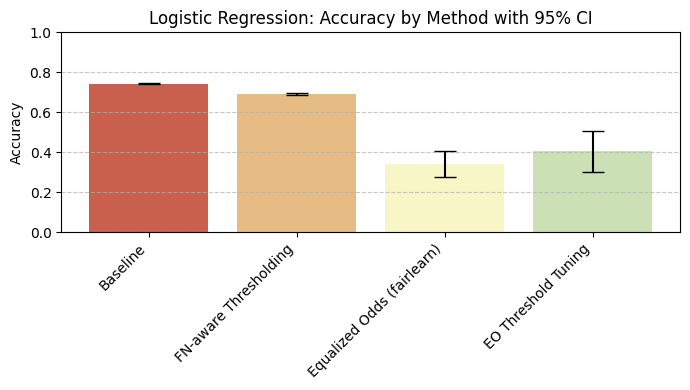

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure yerr is half-width CI
df["yerr"] = df["CI_upper"] - df["Accuracy"]

# Define custom colors (from original plot)
colors = ['#c95f4d', '#e6bc84', '#f8f6c6', '#cce0b5']  # Match original bar colors

# Plot
plt.figure(figsize=(7, 4))
x = np.arange(len(df))
bars = plt.bar(x, df["Accuracy"], yerr=df["yerr"], capsize=8, color=colors[:len(df)])

# Axis formatting
plt.xticks(x, df["Method"], rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Logistic Regression: Accuracy by Method with 95% CI")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("lr_accuracy.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()


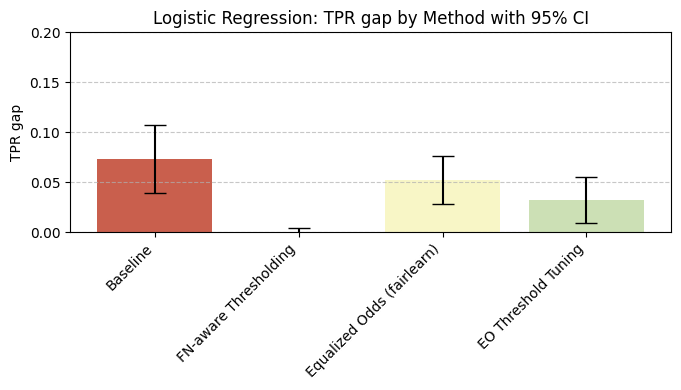

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure yerr is half-width CI
df_TPR_gap["yerr"] = df_TPR_gap["CI_upper"] - df_TPR_gap["TPR_gap"]

# Define custom colors (from original plot)
colors = ['#c95f4d', '#e6bc84', '#f8f6c6', '#cce0b5']  # Match original bar colors

# Plot
plt.figure(figsize=(7, 4))
x = np.arange(len(df_TPR_gap))
bars = plt.bar(x, df_TPR_gap["TPR_gap"], yerr=df_TPR_gap["yerr"], capsize=8, color=colors[:len(df)])

# Axis formatting
plt.xticks(x, df_TPR_gap["Method"], rotation=45, ha='right')
plt.ylabel("TPR gap")
plt.ylim(0, 0.2)
plt.title("Logistic Regression: TPR gap by Method with 95% CI")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("lr_tpr_gap.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()

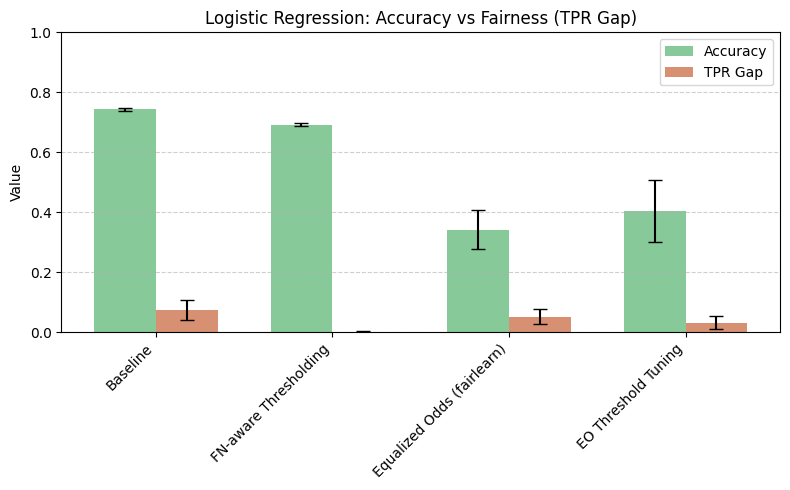

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure error bars are half-width
df["acc_err"] = df["CI_upper"] - df["Accuracy"]
df_TPR_gap["gap_err"] = df_TPR_gap["CI_upper"] - df_TPR_gap["TPR_gap"]

# Shared x-axis
methods = df["Method"]
x = np.arange(len(methods))  # label locations
width = 0.35  # width of bars

# Plot setup
fig, ax = plt.subplots(figsize=(8, 5))

# Accuracy bars
acc_bars = ax.bar(x - width/2, df["Accuracy"], width, yerr=df["acc_err"],
                  label="Accuracy", capsize=5, color='#88c999')

# TPR gap bars
gap_bars = ax.bar(x + width/2, df_TPR_gap["TPR_gap"], width, yerr=df_TPR_gap["gap_err"],
                  label="TPR Gap", capsize=5, color='#d79072')

# Axis formatting
ax.set_ylabel("Value")
ax.set_ylim(0, 1.0)
ax.set_title("Logistic Regression: Accuracy vs Fairness (TPR Gap)")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Layout and save
plt.tight_layout()
plt.savefig("lr_accuracy_vs_fairness.pdf", bbox_inches='tight')
plt.show()


### XGBoost

In [48]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# create the model
xgb_model = XGBClassifier(
    max_depth=3,             # shallow trees reduce majority-class dominance
    learning_rate=0.05,
    n_estimators=500,        # more boosting rounds
    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=1,      # allows splits that capture minority class
    gamma=0,                 # allow more flexible trees
    scale_pos_weight=10, # tune manually
    eval_metric='logloss'
)

# train
xgb_model.fit(X_train, y_train.values.ravel())

# predict
y_proba = xgb_model.predict_proba(X_test)[:,1]

y_pred = xgb_model.predict(X_test)
y_hat = (y_proba > 0.25).astype(int)

# evaluate
print("Accuracy:", accuracy_score(y_test.values.ravel(), y_hat))

Accuracy: 0.8105906313645621


In [49]:
y_prob = xgb_model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test.values.ravel(), y_prob)
print(auc)

0.801247029672807


In [50]:
cm = confusion_matrix(y_test.values.ravel(), y_hat)
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

TPR = TP / (TP + FN)  # True Positive Rate
TNR = TN / (TN + FP)  # True Negative Rate
FNR = FN / (TP + FN)  # False Negative Rate
FPR = FP / (TN + FP)  # False Positive Rate

# Output metrics
print(f"TPR (True Positive Rate): {TPR}")
print(f"TNR (True Negative Rate): {TNR}")
print(f"FNR (False Negative Rate): {FNR}")
print(f"FPR (False Positive Rate): {FPR}")

TPR (True Positive Rate): 0.6037735849056604
TNR (True Negative Rate): 0.8223896663078579
FNR (False Negative Rate): 0.39622641509433965
FPR (False Positive Rate): 0.17761033369214208


In [51]:
# rewrite this


from sklearn.metrics import confusion_matrix

# Convert y_test and y_pred to 1D arrays
y_proba = xgb_model.predict_proba(X_test)[:,1]
y_true = y_test.values.ravel()
y_hat = (y_proba > 0.15).astype(int)

def true_positive_rate(y_true_group, y_pred_group):
    tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

# Split by gender
male_idx = (gender_test == 1)
female_idx = (gender_test == 0)

# TPR for each group
tpr_male = true_positive_rate(y_true[male_idx], y_hat[male_idx])
tpr_female = true_positive_rate(y_true[female_idx], y_hat[female_idx])

print("TPR Male:", tpr_male)
print("TPR Female:", tpr_female)

# Equalized odds difference (TPR gap)
equalized_odds_TPR_gap = abs(tpr_male - tpr_female)
print("Equalized Odds TPR Gap:", equalized_odds_TPR_gap)

TPR Male: 0.8333333333333334
TPR Female: 0.6857142857142857
Equalized Odds TPR Gap: 0.14761904761904765


In [52]:
def xgb_tuned():
    return XGBClassifier(
        max_depth=3,             # shallow trees reduce majority-class dominance
        learning_rate=0.05,
        n_estimators=500,        # more boosting rounds
        subsample=0.8,
        colsample_bytree=0.8,

        min_child_weight=1,      # allows splits that capture minority class
        gamma=0,                 # allow more flexible trees
        scale_pos_weight=10, # tune manually
        eval_metric='logloss'
    )

compute_tpr_fixed_thresholds(
    X=X,
    y=y,
    gender=(gender_col == 'Male').astype(int),
    model_fn=xgb_tuned,
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    threshold_male=0.15,
    threshold_female=0.15,
    n_splits=50
)

Fixed thresholds: Male = 0.15, Female = 0.15
TPR Male: 0.807 ± 0.027 (95% CI)
TPR Female: 0.737 ± 0.027 (95% CI)
Equalized Odds TPR Gap: 0.070 ± 0.035 (95% CI)
Overall Accuracy: 0.715 ± 0.004 (95% CI)


In [53]:
# Create an empty dataframe
df = pd.DataFrame(columns=["Method", "Accuracy", "CI_lower", "CI_upper"])
row1 = {
    "Method": "Baseline",
    "Accuracy": 0.715,
    "CI_lower": 0.711,  # always just predicts 0
    "CI_upper": 0.719  
}
df = pd.concat([df, pd.DataFrame([row1])], ignore_index=True)

/var/folders/sb/qf31rt690tl85rzl99t4n0600000gn/T/ipykernel_43799/547841987.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([row1])], ignore_index=True)


In [54]:
df_TPR_gap = pd.DataFrame(columns=["Method", "TPR_gap", "CI_lower", "CI_upper"])
row_TPR_1 = {
    "Method": "Baseline",
    "TPR_gap": 0.113,
    "CI_lower": 0.088,  # always just predicts 0
    "CI_upper": 0.138
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_1])], ignore_index=True)

/var/folders/sb/qf31rt690tl85rzl99t4n0600000gn/T/ipykernel_43799/1289496286.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_1])], ignore_index=True)


#### Post-processing technique: Different threshold for women

In [55]:
from sklearn.metrics import confusion_matrix, roc_curve

male_true = y_true[male_idx]
female_true = y_true[female_idx]
male_proba = y_proba[male_idx]
female_proba = y_proba[female_idx]

# Fixed male threshold
threshold_male = 0.15
male_pred = (male_proba > threshold_male).astype(int)

# Function to compute TPR
def compute_tpr(y_true_group, y_pred_group):
    tn, fp, fn, tp = confusion_matrix(y_true_group, y_pred_group).ravel()
    return tp / (tp + fn) if (tp + fn) > 0 else 0

# Target TPR = Male TPR
tpr_male = compute_tpr(male_true, male_pred)
print(f"TPR (Male): {tpr_male:.3f}")

# Find threshold for females to match TPR
fpr, tpr, thresholds = roc_curve(female_true, female_proba)
closest_idx = np.argmin(np.abs(tpr - tpr_male))
threshold_female = thresholds[closest_idx]
print(f"Selected Female Threshold: {threshold_female:.3f}")

# Apply thresholds
y_hat_groupwise = np.zeros_like(y_proba)
y_hat_groupwise[male_idx] = (male_proba > threshold_male).astype(int)
y_hat_groupwise[female_idx] = (female_proba > threshold_female).astype(int)

# Final TPRs
tpr_female_adj = compute_tpr(female_true, y_hat_groupwise[female_idx])
tpr_male_adj = compute_tpr(male_true, y_hat_groupwise[male_idx])
tpr_gap = abs(tpr_female_adj - tpr_male_adj)

# Accuracy
accuracy_adj = accuracy_score(y_true, y_hat_groupwise)

# Print metrics
print(f"TPR (Female, Adjusted): {tpr_female_adj:.3f}")
print(f"TPR (Male, Adjusted):   {tpr_male_adj:.3f}")
print(f"Equal Opportunity Gap:  {tpr_gap:.3f}")
print(f"Accuracy (Adjusted):    {accuracy_adj:.3f}")

TPR (Male): 0.833
Selected Female Threshold: 0.047
TPR (Female, Adjusted): 0.800
TPR (Male, Adjusted):   0.833
Equal Opportunity Gap:  0.033
Accuracy (Adjusted):    0.628


In [56]:
# tradeoff curve?
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
def compute_tpr_fpr(y_true, y_proba, threshold):
    y_pred = (y_proba > threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    return tpr, fpr


thresholds = np.linspace(0, 1, 500)

tpr_female_curve = []
fpr_female_curve = []

for th in thresholds:
    tpr, fpr = compute_tpr_fpr(female_true, female_proba, th)
    tpr_female_curve.append(tpr)
    fpr_female_curve.append(fpr)

tpr_female_curve = np.array(tpr_female_curve)
fpr_female_curve = np.array(fpr_female_curve)

threshold_male = 0.15
tpr_male, fpr_male = compute_tpr_fpr(male_true, male_proba, threshold_male)



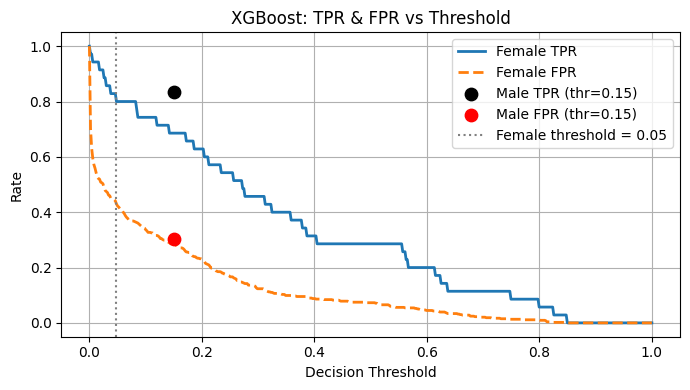

In [57]:
plt.figure(figsize=(7, 4))

# Female curves
plt.plot(thresholds, tpr_female_curve, label="Female TPR", linewidth=2)
plt.plot(thresholds, fpr_female_curve, label="Female FPR", linewidth=2, linestyle="--")

# Male fixed-threshold points
plt.scatter(
    [threshold_male], [tpr_male],
    color="black", s=80, zorder=5, label="Male TPR (thr=0.15)"
)
plt.scatter(
    [threshold_male], [fpr_male],
    color="red", s=80, zorder=5, label="Male FPR (thr=0.15)"
)

# Optional: mark selected female threshold (≈0.37)
plt.axvline(
    x=threshold_female, color="gray", linestyle=":", label=f"Female threshold = {threshold_female:.2f}"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Rate")
plt.title("XGBoost: TPR & FPR vs Threshold")
plt.legend()
plt.grid(True)

plt.savefig("xgb_TPR_FPR.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()

In [58]:
compute_tpr_fixed_thresholds(
    X=X,
    y=y,
    gender=(gender_col == 'Male').astype(int),
    model_fn=xgb_tuned,
    cols_to_scale=['age', 'avg_glucose_level', 'bmi'],
    threshold_male=0.15,
    threshold_female=0.10,
    n_splits=50
)

Fixed thresholds: Male = 0.15, Female = 0.1
TPR Male: 0.807 ± 0.028 (95% CI)
TPR Female: 0.796 ± 0.026 (95% CI)
Equalized Odds TPR Gap: 0.011 ± 0.035 (95% CI)
Overall Accuracy: 0.682 ± 0.005 (95% CI)


In [60]:
row2 = {
    "Method": "FN-aware thresholding",
    "Accuracy": 0.682,
    "CI_lower": 0.677,  # always just predicts 0
    "CI_upper": 0.687  
}
df = pd.concat([df, pd.DataFrame([row2])], ignore_index=True)

In [59]:
row_TPR_2 = {
    "Method": "FN-aware thresholding",
    "TPR_gap": 0.011,
    "CI_lower": -0.024,  # always just predicts 0
    "CI_upper": 0.046
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_2])], ignore_index=True)

Again accuracy decrease

#### Learning with fairness constraints?

In [61]:
xgb_model_f = XGBClassifier(
    max_depth=3,             # shallow trees reduce majority-class dominance
    learning_rate=0.05,
    n_estimators=500,        # more boosting rounds
    subsample=0.8,
    colsample_bytree=0.8,

    min_child_weight=1,      # allows splits that capture minority class
    gamma=0,                 # allow more flexible trees
    scale_pos_weight=10, # tune manually
    eval_metric='logloss'
)

constraint = EqualizedOdds()
mitigator = ExponentiatedGradient(xgb_model_f, constraint)
mitigator.fit(X_train, y_train.values.ravel(), sensitive_features=gender_train)

y_hat = mitigator.predict(X_test)

# TPR for each group
tpr_male = true_positive_rate(y_true[male_idx], y_hat[male_idx])
tpr_female = true_positive_rate(y_true[female_idx], y_hat[female_idx])

print("TPR Male:", tpr_male)
print("TPR Female:", tpr_female)

# Equalized odds difference (TPR gap)
equalized_odds_TPR_gap = abs(tpr_male - tpr_female)
print("Equalized Odds TPR Gap:", equalized_odds_TPR_gap)

TPR Male: 0.16666666666666666
TPR Female: 0.11428571428571428
Equalized Odds TPR Gap: 0.052380952380952375


In [62]:
cm = confusion_matrix(y_test.values.ravel(), y_hat)
TP = cm[1, 1]
TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]

TPR = TP / (TP + FN)  # True Positive Rate
TNR = TN / (TN + FP)  # True Negative Rate
FNR = FN / (TP + FN)  # False Negative Rate
FPR = FP / (TN + FP)  # False Positive Rate

# Output metrics
print(f"TPR (True Positive Rate): {TPR}")
print(f"TNR (True Negative Rate): {TNR}")
print(f"FNR (False Negative Rate): {FNR}")
print(f"FPR (False Positive Rate): {FPR}")

TPR (True Positive Rate): 0.1320754716981132
TNR (True Negative Rate): 0.9634015069967707
FNR (False Negative Rate): 0.8679245283018868
FPR (False Positive Rate): 0.03659849300322928


Also won't work without thresholding

In [63]:
# try different thresholds???
# Get the classifiers and their weights
classifiers = mitigator.predictors_
weights = mitigator.weights_

# Compute the weighted probability predictions
probs = np.zeros(X_test.shape[0])

for clf, w in zip(classifiers, weights):
    probs += w * clf.predict_proba(X_test)[:, 1]

# Now you have the soft predictions
y_probs = probs

thresholds = np.linspace(0.05, 0.15, 20)
results = []

for thresh in thresholds:
    y_hat_thresh = (y_probs >= thresh).astype(int)

    tpr_male = true_positive_rate(y_true[male_idx], y_hat_thresh[male_idx])
    tpr_female = true_positive_rate(y_true[female_idx], y_hat_thresh[female_idx])
    eq_odds_gap = abs(tpr_male - tpr_female)
    overall_acc = accuracy_score(y_true, y_hat_thresh)

    results.append((thresh, tpr_male, tpr_female, eq_odds_gap, overall_acc))

import pandas as pd
results_df = pd.DataFrame(results, columns=['threshold', 'TPR_male', 'TPR_female', 'TPR_gap', 'accuracy'])
print(results_df.sort_values('TPR_gap').head(5))

   threshold  TPR_male  TPR_female   TPR_gap  accuracy
9   0.097368  0.666667    0.600000  0.066667  0.749491
6   0.081579  0.666667    0.600000  0.066667  0.719959
7   0.086842  0.666667    0.600000  0.066667  0.728106
8   0.092105  0.666667    0.600000  0.066667  0.735234
2   0.060526  0.833333    0.742857  0.090476  0.674134


In [64]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
import numpy as np

def fairlearn_xgb_with_ci(X, y, gender, cols_to_scale, threshold=0.10, n_splits=30, test_size=0.2):
    splitter = StratifiedShuffleSplit(n_splits=n_splits, test_size=test_size, random_state=42)

    tpr_male_list = []
    tpr_female_list = []
    gap_list = []
    acc_list = []

    for train_idx, test_idx in splitter.split(X, y):
        # Split data
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # Define XGBoost model
        xgb_model_f = XGBClassifier(
            max_depth=3,
            learning_rate=0.05,
            n_estimators=500,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            gamma=0,
            scale_pos_weight=10,
            eval_metric='logloss'
        )

        # Fairness constraint
        constraint = EqualizedOdds()
        mitigator = ExponentiatedGradient(xgb_model_f, constraint)
        mitigator.fit(X_train, y_train.values.ravel(), sensitive_features=gender_train)

        # Get weighted probability predictions from ensemble
        probs = np.zeros(X_test.shape[0])
        for clf, w in zip(mitigator.predictors_, mitigator.weights_):
            probs += w * clf.predict_proba(X_test)[:, 1]

        # Apply fixed threshold
        y_pred = (probs >= threshold).astype(int)
        y_true = y_test.values.ravel()

        # Group masks
        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else 0

        tpr_m = tpr(y_true[male_idx], y_pred[male_idx])
        tpr_f = tpr(y_true[female_idx], y_pred[female_idx])
        gap = (tpr_m - tpr_f)
        acc = accuracy_score(y_true, y_pred)

        tpr_male_list.append(tpr_m)
        tpr_female_list.append(tpr_f)
        gap_list.append(gap)
        acc_list.append(acc)

    # Summary function
    def summarize(name, values):
        values = np.array(values)
        mean = np.mean(values)
        std = np.std(values)
        ci95 = 1.96 * std / np.sqrt(len(values))
        print(f"{name}: {mean:.3f} ± {ci95:.3f} (95% CI)")

    print(f"Using fixed threshold: {threshold:.3f}")
    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)
    summarize("Equalized Odds Gap", gap_list)
    summarize("Accuracy", acc_list)


In [65]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds

def fairlearn_xgb_with_bootstrap_ci(
    X, y, gender, cols_to_scale,
    threshold=0.10,
    n_splits=30, test_size=0.2,
    ci_level=95, n_bootstrap=10000
):
    splitter = StratifiedShuffleSplit(
        n_splits=n_splits, test_size=test_size, random_state=42
    )

    tpr_male_list = []
    tpr_female_list = []
    gap_list = []
    acc_list = []

    for train_idx, test_idx in splitter.split(X, y):
        # Split
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        gender_train, gender_test = gender.iloc[train_idx].copy(), gender.iloc[test_idx].copy()

        # Scale
        scaler = StandardScaler()
        X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        # XGBoost base model
        xgb_model = XGBClassifier(
            max_depth=3,
            learning_rate=0.05,
            n_estimators=500,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            gamma=0,
            scale_pos_weight=10,
            eval_metric='logloss',
            verbosity=0
        )

        # Fairlearn mitigator
        constraint = EqualizedOdds()
        mitigator = ExponentiatedGradient(xgb_model, constraint)
        mitigator.fit(
            X_train,
            y_train.values.ravel(),
            sensitive_features=gender_train
        )

        # ---- Ensemble probability prediction ----
        probs = np.zeros(X_test.shape[0])
        for clf, w in zip(mitigator.predictors_, mitigator.weights_):
            probs += w * clf.predict_proba(X_test)[:, 1]

        y_pred = (probs >= threshold).astype(int)
        y_true = y_test.values.ravel()

        # Group masks
        male_idx = (gender_test == 1).values
        female_idx = (gender_test == 0).values

        def tpr(y_t, y_p):
            tn, fp, fn, tp = confusion_matrix(
                y_t, y_p, labels=[0, 1]
            ).ravel()
            return tp / (tp + fn) if (tp + fn) > 0 else np.nan

        tpr_m = tpr(y_true[male_idx], y_pred[male_idx])
        tpr_f = tpr(y_true[female_idx], y_pred[female_idx])
        acc = accuracy_score(y_true, y_pred)

        if not np.isnan(tpr_m) and not np.isnan(tpr_f):
            tpr_male_list.append(tpr_m)
            tpr_female_list.append(tpr_f)
            gap_list.append((tpr_m - tpr_f))
            acc_list.append(acc)

    # ---- Bootstrap CI ----
    def bootstrap_ci(values):
        values = np.asarray(values)
        if len(values) == 0:
            return np.nan, np.nan
        boot_means = [
            np.mean(np.random.choice(values, size=len(values), replace=True))
            for _ in range(n_bootstrap)
        ]
        lower = np.percentile(boot_means, (100 - ci_level) / 2)
        upper = np.percentile(boot_means, 100 - (100 - ci_level) / 2)
        mean = np.mean(values)
        half_width = (upper - lower) / 2
        return mean, half_width

    def summarize(name, values):
        mean, hw = bootstrap_ci(values)
        print(f"{name}: {mean:.3f} ± {hw:.3f} ({ci_level}% CI)")

    print(f"Fairlearn + XGBoost | Fixed threshold = {threshold:.3f}")
    summarize("TPR Male", tpr_male_list)
    summarize("TPR Female", tpr_female_list)
    summarize("Equalized Odds TPR Gap", gap_list)
    summarize("Accuracy", acc_list)


In [66]:
fairlearn_xgb_with_bootstrap_ci(
    X=X,
    y=y,
    gender=(gender_col == "Male").astype(int),
    cols_to_scale=["age", "avg_glucose_level", "bmi"],
    threshold=0.10,
    n_splits=20
)

Fairlearn + XGBoost | Fixed threshold = 0.100
TPR Male: 0.786 ± 0.044 (95% CI)
TPR Female: 0.742 ± 0.044 (95% CI)
Equalized Odds TPR Gap: 0.043 ± 0.048 (95% CI)
Accuracy: 0.719 ± 0.014 (95% CI)


In [70]:
row4 = {
    "Method": "EO Threshold Tuning",
    "Accuracy": 0.719,
    "CI_lower": 0.705,  # always just predicts 0
    "CI_upper": 0.733  
}
df = pd.concat([df, pd.DataFrame([row4])], ignore_index=True)

In [71]:
row_TPR_4 = {
    "Method": "EO Threshold Tuning",
    "TPR_gap": 0.043,
    "CI_lower": -0.005,  # always just predicts 0
    "CI_upper": 0.091
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_4])], ignore_index=True)

In [67]:
fairlearn_xgb_with_bootstrap_ci(
    X=X,
    y=y,
    gender=(gender_col == "Male").astype(int),
    cols_to_scale=["age", "avg_glucose_level", "bmi"],
    threshold=0.50, # original with 0.5 threshold
    n_splits=20
)

Fairlearn + XGBoost | Fixed threshold = 0.500
TPR Male: 0.218 ± 0.050 (95% CI)
TPR Female: 0.133 ± 0.042 (95% CI)
Equalized Odds TPR Gap: 0.085 ± 0.039 (95% CI)
Accuracy: 0.933 ± 0.005 (95% CI)


In [68]:
row3 = {
    "Method": "Equalized Odds (fairlearn)",
    "Accuracy": 0.933,
    "CI_lower": 0.928,  # always just predicts 0
    "CI_upper": 0.938  
}
df = pd.concat([df, pd.DataFrame([row3])], ignore_index=True)

In [69]:
row_TPR_3 = {
    "Method": "Equalized Odds (fairlearn)",
    "TPR_gap": 0.098,
    "CI_lower": 0.065,  # always just predicts 0
    "CI_upper": 0.131
}
df_TPR_gap = pd.concat([df_TPR_gap, pd.DataFrame([row_TPR_3])], ignore_index=True)

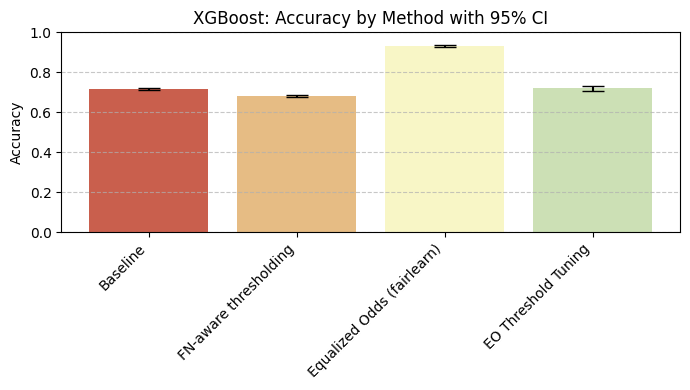

In [72]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure yerr is half-width CI
df["yerr"] = df["CI_upper"] - df["Accuracy"]

# Define custom colors (from original plot)
colors = ['#c95f4d', '#e6bc84', '#f8f6c6', '#cce0b5']  # Match original bar colors

# Plot
plt.figure(figsize=(7, 4))
x = np.arange(len(df))
bars = plt.bar(x, df["Accuracy"], yerr=df["yerr"], capsize=8, color=colors[:len(df)])

# Axis formatting
plt.xticks(x, df["Method"], rotation=45, ha='right')
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("XGBoost: Accuracy by Method with 95% CI")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("xgb_accuracy.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()

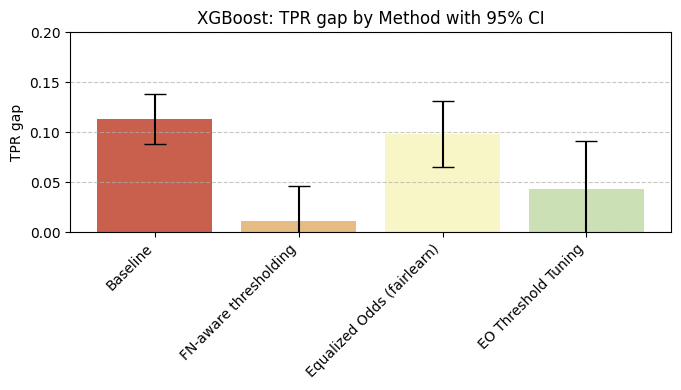

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure yerr is half-width CI
df_TPR_gap["yerr"] = df_TPR_gap["CI_upper"] - df_TPR_gap["TPR_gap"]

# Define custom colors (from original plot)
colors = ['#c95f4d', '#e6bc84', '#f8f6c6', '#cce0b5']  # Match original bar colors

# Plot
plt.figure(figsize=(7, 4))
x = np.arange(len(df_TPR_gap))
bars = plt.bar(x, df_TPR_gap["TPR_gap"], yerr=df_TPR_gap["yerr"], capsize=8, color=colors[:len(df)])

# Axis formatting
plt.xticks(x, df_TPR_gap["Method"], rotation=45, ha='right')
plt.ylabel("TPR gap")
plt.ylim(0, 0.2)
plt.title("XGBoost: TPR gap by Method with 95% CI")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.savefig("xgb_tpr_gap.pdf", bbox_inches='tight')

plt.tight_layout()
plt.show()

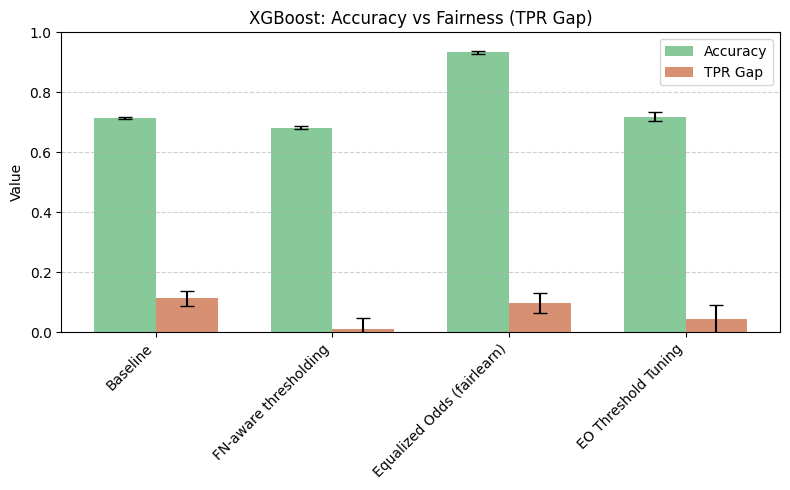

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure error bars are half-width
df["acc_err"] = df["CI_upper"] - df["Accuracy"]
df_TPR_gap["gap_err"] = df_TPR_gap["CI_upper"] - df_TPR_gap["TPR_gap"]

# Shared x-axis
methods = df["Method"]
x = np.arange(len(methods))  # label locations
width = 0.35  # width of bars

# Plot setup
fig, ax = plt.subplots(figsize=(8, 5))

# Accuracy bars
acc_bars = ax.bar(x - width/2, df["Accuracy"], width, yerr=df["acc_err"],
                  label="Accuracy", capsize=5, color='#88c999')

# TPR gap bars
gap_bars = ax.bar(x + width/2, df_TPR_gap["TPR_gap"], width, yerr=df_TPR_gap["gap_err"],
                  label="TPR Gap", capsize=5, color='#d79072')

# Axis formatting
ax.set_ylabel("Value")
ax.set_ylim(0, 1.0)
ax.set_title("XGBoost: Accuracy vs Fairness (TPR Gap)")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Layout and save
plt.tight_layout()
plt.savefig("xgb_tradeoff.pdf", bbox_inches='tight')
plt.show()